[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/brianjalaian/CAP6606_ML_ISR/blob/main/modules/05_dimensionality_reduction/AdditionalExample-BAJ-release.ipynb)
[![Open in Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/brianjalaian/CAP6606_ML_ISR/blob/main/modules/05_dimensionality_reduction/AdditionalExample-BAJ-release.ipynb)


# Simple PCA Example with Dummy Numebrs

This code generates a 100x3 random data matrix and creates a 3D scatter plot of the original data. The projection='3d' argument creates a 3D plot and the `ax.scatter(X[:, 0], X[:, 1], X[:, 2])` line specifies the x, y, and z coordinates of the data points. The code then applies PCA to reduce the dimensionality to two dimensions, and creates a 2D scatter plot of the reduced data with the first principal component on the x-axis and the second principal component on the y-axis. You can see how the 3D plot visualizes the original high-dimensional data, and how the 2D plot visualizes the same data in a more meaningful way.

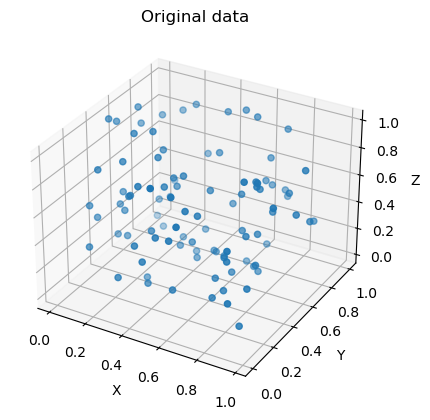

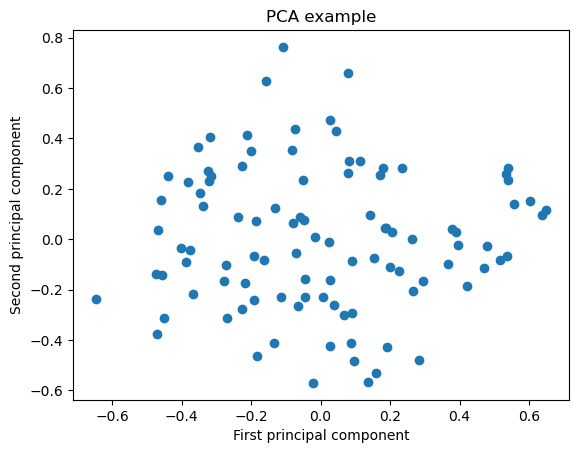

In [10]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Generate random three-dimensional data
np.random.seed(123)
X = np.random.rand(100, 3)

# Plot the original data in a 3D scatter plot and save it
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Original data')
fig.savefig('original_data.png', dpi=300)

# Perform PCA to reduce dimensionality to two dimensions
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)

# Plot the reduced data in a scatter plot and save it
fig2 = plt.figure()
plt.scatter(X_reduced[:, 0], X_reduced[:, 1])
plt.xlabel('First principal component')
plt.ylabel('Second principal component')
plt.title('PCA example')
fig2.savefig('reduced_data.png', dpi=300)

plt.show()

# Additional Examples on "Compressing Data via Dimentionality Reduction

## PCA Example

The code below loads the iris dataset from scikit-learn, performs PCA to reduce the dimensionality of the dataset from 4 to 2, and then plots the data in the new two-dimensional space with the x-axis representing the first principal component and the y-axis representing the second principal component. The color of each point corresponds to its class label in the iris dataset.

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris

In [2]:
# Load iris dataset
iris = load_iris()
X = iris.data

To find the number of features in your dataset before performing PCA, you can simply access the shape attribute of the input data. For example, if your input data is stored in a numpy array X, you can use the following code to find the number of features:

In [5]:
num_features = X.shape[1]
print('Number of features: ', num_features)

Number of features:  4


In [6]:
# Print number of features and feature names
num_features = len(iris.feature_names)
print('Number of features:', num_features)
print('Feature names:', iris.feature_names)

Number of features: 4
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [7]:
# Perform PCA and project data onto the first two principal components
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)

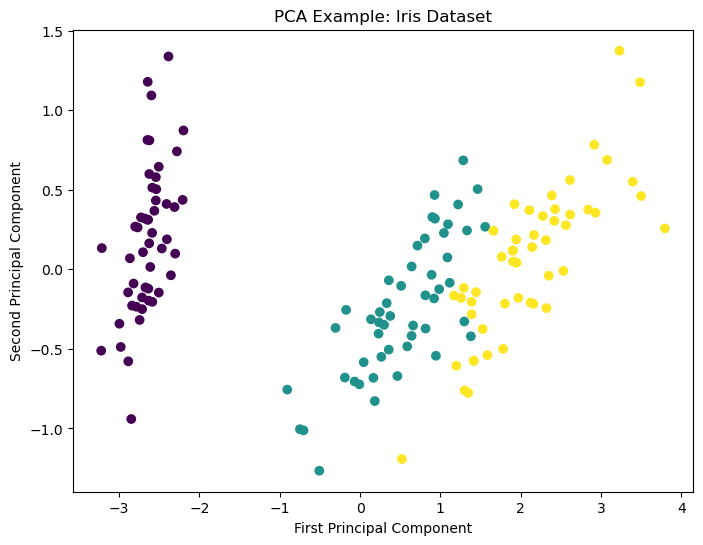

In [8]:
# Plot the data in the new two-dimensional space
plt.figure(figsize=(8, 6))
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=iris.target, cmap='viridis')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('PCA Example: Iris Dataset')
plt.show()

# LDA Example

In the example below, the code snippet loads the MNIST dataset from OpenML and performs dimensionality reduction using LDA (Linear Discriminant Analysis) to project the high-dimensional data (784 features) into a 2-dimensional space. The reduced data is then plotted using a scatter plot, where the color of each point represents the corresponding label of the image.

Before applying LDA, the categorical labels of the dataset are encoded as numerical values using the `LabelEncoder` class. Finally, the scatter plot is created using the `matplotlib.pyplot` library, where the "c" argument of the scatter function is set to the encoded labels to color each point based on its label.

In [10]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

In [11]:
# Load the MNIST image classification dataset from OpenML
X, y = fetch_openml('mnist_784', version=1, return_X_y=True)

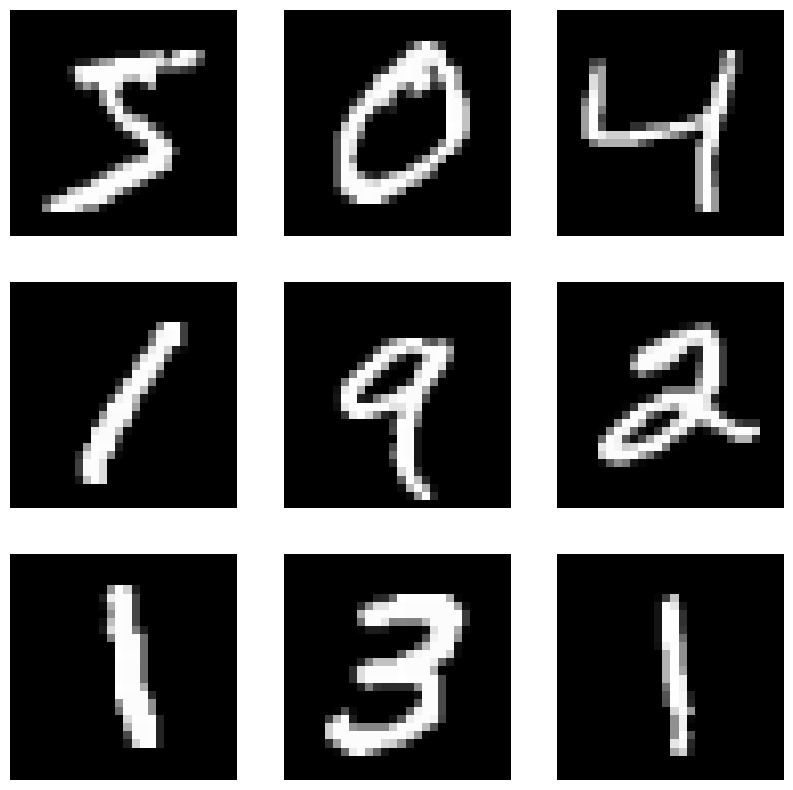

In [14]:
# Visualize some test samples
fig, axs = plt.subplots(3, 3, figsize=(10, 10))
axs = axs.flatten()
for i in range(9):
    img = X.values[i].reshape(28, 28)
    axs[i].imshow(img, cmap='gray')
    axs[i].axis('off')
plt.show()

In [15]:
# Convert pixel values to float and scale to [0, 1]
X = X.astype('float32') / 255.0

In [16]:
# Reduce the dimensionality of the data from 784 to 2 using LDA
lda = LinearDiscriminantAnalysis(n_components=2)
X_reduced = lda.fit_transform(X, y)

In [17]:
# Convert the categorical labels to numerical values
le = LabelEncoder()
y = le.fit_transform(y)

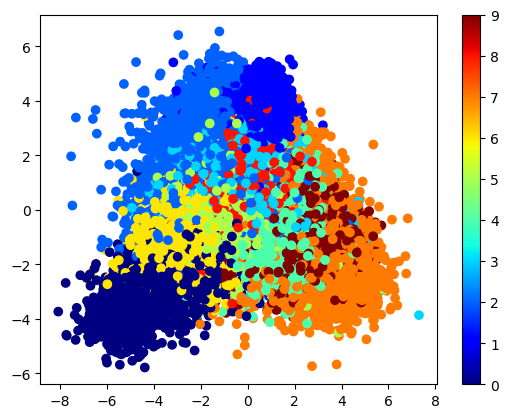

In [20]:
# Plot the reduced data
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y, cmap='jet')
plt.colorbar()
plt.savefig('MINIST_reduced_data.png', dpi=300)
plt.show()

# LDA example:

This code loads the MNIST dataset and splits it into training and testing sets. It then applies LDA to reduce the dimensionality of the training data and trains a logistic regression classifier on the reduced data. The resulting classifier is then evaluated on the testing data to compute the accuracy of the classifier.

Here is a brief explanation of each step:

- The `fetch_openml` function is used to load the MNIST dataset from OpenML. The data is returned as two arrays `X` and `y`, where `X` contains the pixel values of the images and `y` contains the corresponding labels.
- The `train_test_split` function is used to split the data into training and testing sets. In this case, the testing set is 20% of the total dataset and is chosen randomly using a seed value of 42 for reproducibility.
- The `LinearDiscriminantAnalysis` class from scikit-learn is used to apply LDA to reduce the dimensionality of the training data. The `n_components` parameter is set to 9, which means that the data is projected onto a 9-dimensional subspace that preserves the most discriminative information between the classes.
- The `fit_transform` method is called on the LDA object to project the training data onto the reduced subspace. The resulting data is stored in the `X_train_lda` array.
- The transform method is called on the LDA object to project the testing data onto the same subspace as the training data. The resulting data is stored in the `X_test_lda array`.
- A logistic regression classifier is created using the `LogisticRegression` class. The `max_iter parameter` is set to 1000 to ensure that the classifier converges to a solution, and the random_state parameter is set to 42 for reproducibility.
- The `fit` method is called on the classifier to train it on the reduced training data.
- The `predict` method is called on the classifier to generate predictions for the testing data.
- The `accuracy_score` function is used to compute the accuracy of the classifier on the testing data.

The resulting accuracy of the classifier is printed to the console.

In [21]:
from sklearn.datasets import fetch_openml
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [22]:
# Load the MNIST dataset
X, y = fetch_openml('mnist_784', version=1, return_X_y=True)

In [23]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
# Apply LDA to reduce the dimensionality of the data
lda = LinearDiscriminantAnalysis(n_components=9)
X_train_lda = lda.fit_transform(X_train, y_train)
X_test_lda = lda.transform(X_test)

In [25]:
# Train a logistic regression classifier on the reduced data
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train_lda, y_train)

LogisticRegression(max_iter=1000, random_state=42)

This code snippet is visualizing 9 test samples from the MNIST dataset using Matplotlib. It creates a figure with a 3x3 grid of subplots, and then iterates over the first 9 samples in the test set. For each sample, it reshapes the 784-pixel image into a 28x28 matrix and displays it in a subplot. Finally, it removes the axis ticks and labels from each subplot and displays the entire figure. This allows you to see what the handwritten digits actually look like in the dataset, which can help you understand how well the classifier is performing.

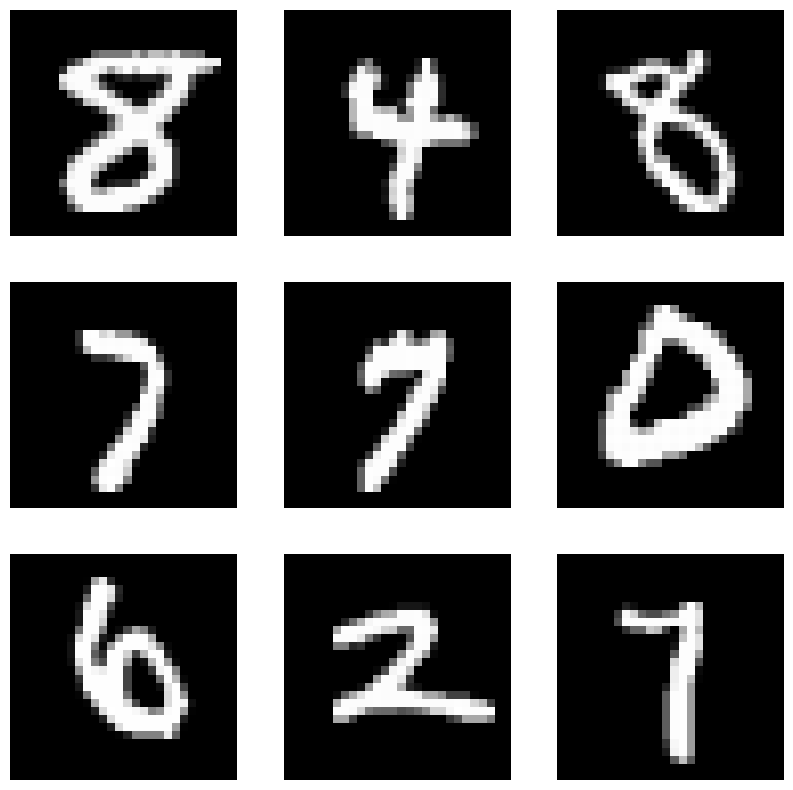

In [26]:
# Visualize some test samples
fig, axs = plt.subplots(3, 3, figsize=(10, 10))
axs = axs.flatten()
for i in range(9):
    img = X_test.values[i].reshape(28, 28)
    axs[i].imshow(img, cmap='gray')
    axs[i].axis('off')
plt.show()

In [27]:
# Evaluate the classifier on the testing data
y_pred = clf.predict(X_test_lda)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.3f}')

Accuracy: 0.884


This code segment demonstrates how to visualize some of the samples that were misclassified by the logistic regression classifier trained on the reduced MNIST dataset obtained by applying LDA.

Here's what the code does:

- It predicts the labels of the test set using the trained logistic regression classifier.
- It creates a boolean array "misclassified" that indicates which samples are misclassified by comparing the predicted labels with the true labels of the test set.
- It extracts the misclassified images and labels using the "misclassified" boolean array.
- It plots a 3x3 grid of images with their corresponding true and predicted labels for the first 9 misclassified samples.

This code allows us to visually inspect the samples that were misclassified by the classifier and helps us understand the types of errors it is making. It's important to understand the types of errors the model is making, as this can guide us towards further model improvements or data preprocessing steps that may improve its performance.

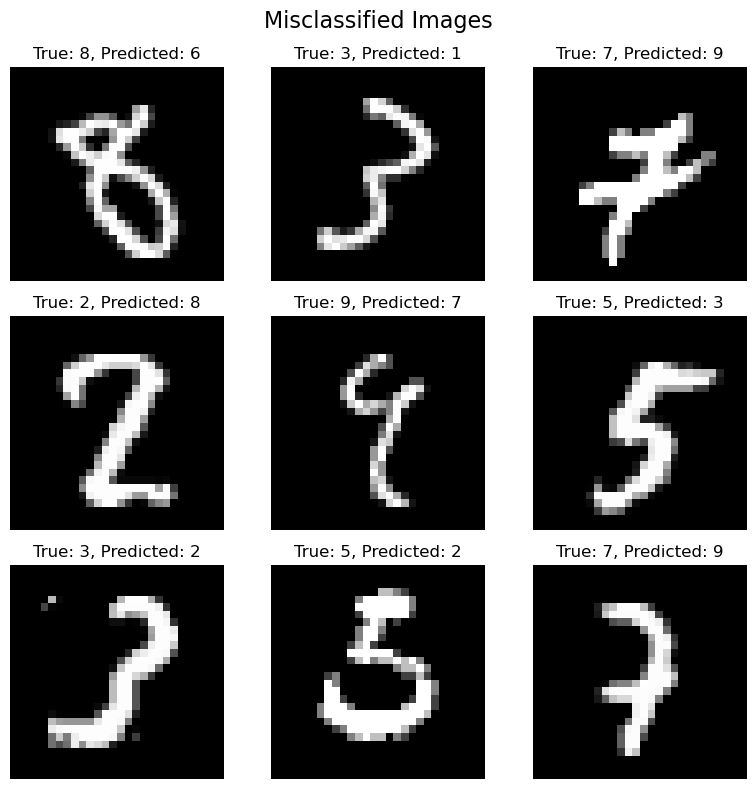

In [28]:
# Get predicted labels for test set
y_pred = clf.predict(X_test_lda)

# Create a boolean array indicating which samples are misclassified
misclassified = y_test != y_pred

# Get the misclassified images and labels
misclassified_images = X_test[misclassified]
misclassified_labels = y_test[misclassified]

# Plot the misclassified images
fig, axs = plt.subplots(3, 3, figsize=(8, 8))
fig.suptitle('Misclassified Images', fontsize=16)

axs = axs.flatten()

for i in range(9):
    img = misclassified_images.values[i].reshape(28, 28)
    axs[i].imshow(img, cmap='gray')
    axs[i].set_title(f'True: {misclassified_labels.values[i]}, Predicted: {y_pred[misclassified][i]}')
    axs[i].axis('off')
    
plt.tight_layout()
plt.show()

# Nonlinear dimensionality reduction and visualization

t-SNE is a popular machine learning algorithm used for dimensionality reduction and data visualization. One of the key strengths of t-SNE is its ability to capture nonlinear relationships in the data. Let's take a look at an example using the make_moons function from the `sklearn.datasets` module.

- `make_moons` is a convenience function for generating a toy dataset of two interleaving half circles. We'll start by generating this dataset and plotting it in its original high-dimensional space:
- As we can see from the output of the bewlow code, the dataset is highly nonlinear and the two half circles are not easily separable in this high-dimensional space. This is where t-SNE comes in. We can use t-SNE to reduce the dimensionality of the dataset to two dimensions and visualize it in a more meaningful way.
- As we can see from the output of the below code, t-SNE has done a great job of capturing the structure of the data. The two half circles are now clearly separated and distinct from each other. This demonstrates the power of t-SNE in visualizing nonlinear data in a way that is more interpretable and intuitive for humans.

Overall, t-SNE is a great tool for exploring the structure of high-dimensional datasets, identifying patterns, and gaining insights into complex data.

/Users/bjalaian/miniconda/envs/machine-learning-book/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/Users/bjalaian/miniconda/envs/machine-learning-book/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


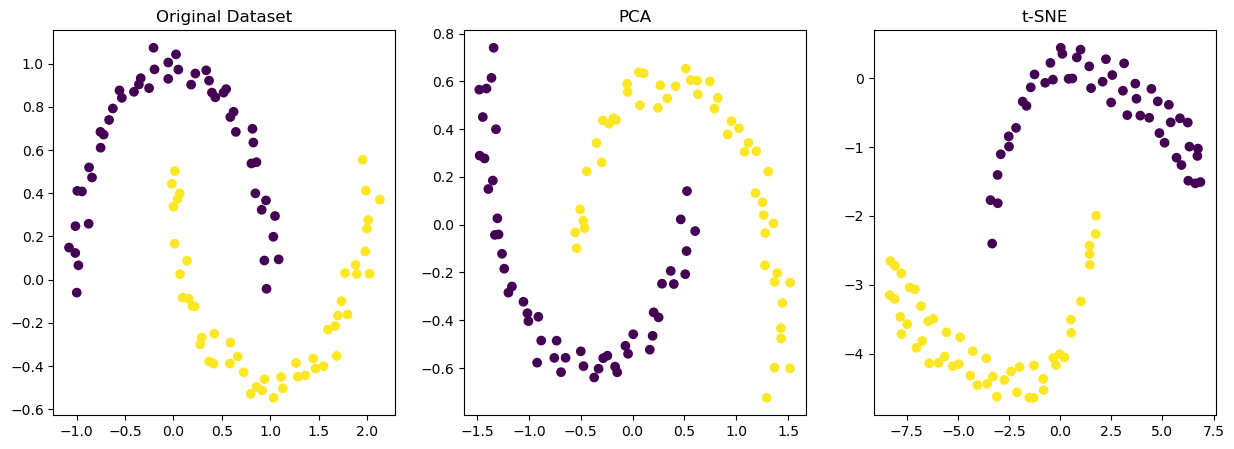

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Generate the dataset
X, y = make_moons(n_samples=100, noise=0.05, random_state=42)

# Reduce the dimensionality using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Reduce the dimensionality using t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X)

# Plot the data
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Plot the original dataset
axs[0].scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')
axs[0].set_title('Original Dataset')

# Plot the PCA-reduced data
axs[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis')
axs[1].set_title('PCA')

# Plot the t-SNE-reduced data
axs[2].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='viridis')
axs[2].set_title('t-SNE')

plt.show()

This code loads the Iris dataset and applies t-SNE to reduce the dimensionality of the data to two dimensions. It then plots the reduced data, with each point colored according to the true class labels. The resulting plot shows that the different flower species form distinct clusters in the reduced two-dimensional space, allowing for easier visualization and analysis of the data. You can replace the Iris dataset with any other high-dimensional dataset to apply t-SNE and gain insights into the structure and relationships between different classes.

# Iris Dataset Example

/Users/bjalaian/miniconda/envs/machine-learning-book/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/Users/bjalaian/miniconda/envs/machine-learning-book/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


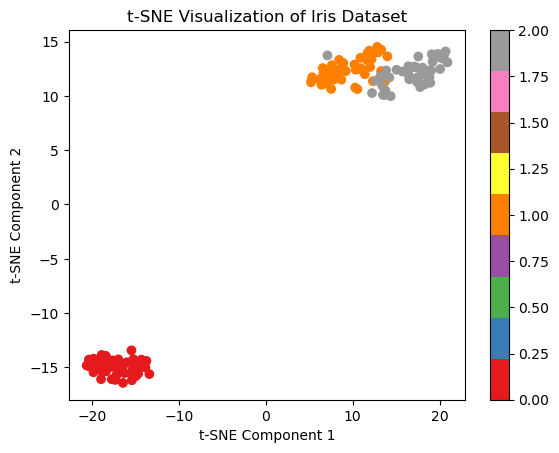

In [37]:
from sklearn.datasets import load_iris
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Load the iris dataset
X, y = load_iris(return_X_y=True)

# Apply t-SNE to reduce the dimensionality of the data to 2 dimensions
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)

# Plot the reduced data, color-coded by the class labels
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='Set1')
plt.colorbar()
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('t-SNE Visualization of Iris Dataset')
plt.show()

In [35]:
X.shape[1]

4

# Wine Datset Example

/Users/bjalaian/miniconda/envs/machine-learning-book/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/Users/bjalaian/miniconda/envs/machine-learning-book/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


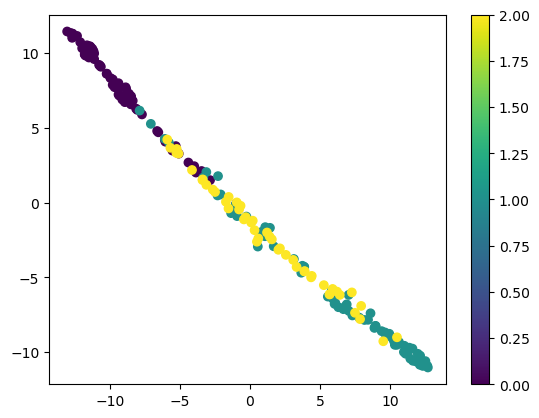

In [38]:
from sklearn.datasets import load_wine
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Load the wine dataset
data, labels = load_wine(return_X_y=True)

# Apply t-SNE to reduce the dimensionality of the data to 2
tsne = TSNE(n_components=2, random_state=42)
data_tsne = tsne.fit_transforvm(data)

# Plot the reduced data
plt.scatter(data_tsne[:, 0], data_tsne[:, 1], c=labels, cmap='viridis')
plt.colorbar()
plt.show()


In [40]:
data.shape[1]

13

In [42]:
np.unique(labels)

array([0, 1, 2])